Görev 1: Kendi Value sınıfını yaz, toplama ve çarpma ile başla. Her yeni Value, kendisini üreten Value'ları ve hangi işlemden çıktığını saklasın. İstersen videodaki gibi computation graph'i graphviz ile çizdir. 

In [11]:
import math

class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.grad = 0.0
        self._backward = lambda: None  

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, _children=(self, other), _op='+') #Görev3

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
            
             
        out._backward = _backward
        
    

        #return Value(self.data + other.data, _children=(self, other), _op='+')
        return out

    def __mul__(self, other):

        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data, _children=(self, other), _op='*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            
        
        out._backward = _backward    
        

        #return Value(self.data * other.data, _children=(self, other), _op='*')
        return out
    
    def tanh(self):

        out = Value(math.tanh(self.data), _children=(self,), _op='tanh')
 
        def _backward():
            self.grad += (1.0 - out.data**2) * out.grad
            
        out._backward = _backward                 

        #return Value(math.tanh(self.data), _children=(self,), _op='tanh')
        return out
    def backward(self):

        self.grad = 1.0

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)   

        for node in reversed(topo):
            node._backward()        
                
    def __radd__(self, other):
        return self + other

    
    def __rmul__(self, other):
        return self * other


    def exp(self):
        out = Value(math.exp(self.data), _children=(self,), _op='exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, _children=(self,), _op=f'**{other}')

        def _backward():
            self.grad += (other * (self.data ** (other - 1))) * out.grad

        out._backward = _backward
        return out

    def __neg__(self):  
        return self * -1


    def __sub__(self, other):  
        return self + (-other)


    def __truediv__(self, other):  
        return self * (other**-1)


In [12]:
a = Value(2.0)
b = Value(3.0)
c = a + b
d = Value(4.0)
e = c * d 

print(e.data)
print(e._prev)
print(e._op)








20.0
{Value(data=5.0, grad=0.0), Value(data=4.0, grad=0.0)}
*


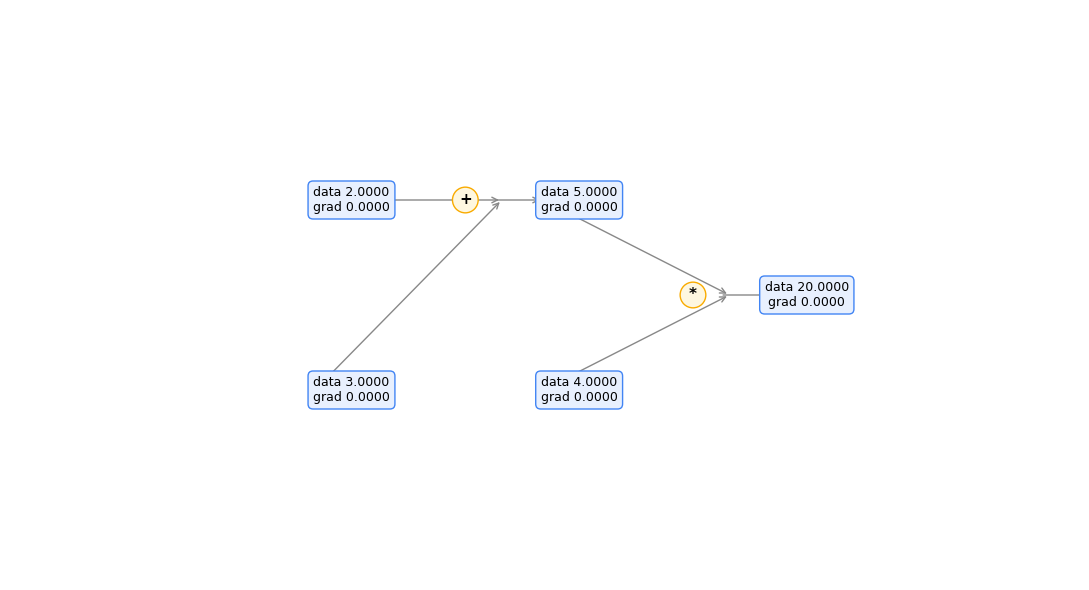

In [13]:

#görselleştirme tarafında yapay zeka kullandım.

from collections import defaultdict
import matplotlib.pyplot as plt



def trace(root):
    """Grafikteki tüm node ve edge'leri (bağlantıları) topluyoruz."""
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def compute_ranks(root):
    """Her node'un kökten (root) uzaklığını hesaplıyoruz -> sütun (x) pozisyonu için."""
    ranks = {}

    def visit(v, r):
        if v not in ranks or ranks[v] < r:
            ranks[v] = r
            for child in v._prev:
                visit(child, r + 1)

    visit(root, 0)
    return ranks


def draw_dot(root, figsize=(11, 6), save_path=None):
    """
    Value grafiğini matplotlib ile çizer (graphviz/dot.exe GEREKTİRMEZ).
    save_path verilirse görseli dosyaya kaydeder (örn. 'graph.png').
    """
    nodes, edges = trace(root)
    ranks = compute_ranks(root)
    max_rank = max(ranks.values()) if ranks else 0

    by_rank = defaultdict(list)
    for n in nodes:
        by_rank[ranks[n]].append(n)

    pos, op_pos = {}, {}
    for r, ns in by_rank.items():
        x = max_rank - r  # kökü sağda, yaprakları solda tutuyoruz (LR görünümü)
        for i, n in enumerate(ns):
            y = i - (len(ns) - 1) / 2
            pos[n] = (x, y)
            if n._op:
                op_pos[n] = (x - 0.5, y)

    fig, ax = plt.subplots(figsize=figsize)

    # child -> (varsa op node'u, yoksa direkt value node'u) ok çiz
    for n1, n2 in edges:
        x1, y1 = pos[n1]
        x2, y2 = op_pos[n2] if n2 in op_pos else pos[n2]
        ax.annotate("", xy=(x2 + 0.16, y2), xytext=(x1 - 0.16, y1),
                    arrowprops=dict(arrowstyle="->", color="#888888"))

    # op node -> value node ok çiz
    for n, (ox, oy) in op_pos.items():
        x, y = pos[n]
        ax.annotate("", xy=(x - 0.16, y), xytext=(ox + 0.12, oy),
                    arrowprops=dict(arrowstyle="->", color="#888888"))

    # value node kutuları (data + grad)
    for n, (x, y) in pos.items():
        ax.text(x, y, f"data {n.data:.4f}\ngrad {n.grad:.4f}",
                ha='center', va='center', fontsize=9,
                bbox=dict(boxstyle="round,pad=0.4", fc="#e8f0fe", ec="#4285f4"))

    # işlem (op) daireleri
    for n, (ox, oy) in op_pos.items():
        ax.text(ox, oy, n._op, ha='center', va='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="circle,pad=0.35", fc="#fef7e0", ec="#f9ab00"))

    ax.set_xlim(-1.5, max_rank + 1.2)
    all_y = [y for _, y in pos.values()] or [0]
    ax.set_ylim(min(all_y) - 1, max(all_y) + 1)
    ax.axis('off')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Görsel '{save_path}' olarak kaydedildi.")

    plt.show()
    return fig


if __name__ == "__main__":
    a = Value(2.0)
    b = Value(3.0)
    c = a + b
    d = Value(4.0)
    e = c * d 
    

    draw_dot(e)


Görev 2: Otomatikleştirmeden önce gradient'leri videodaki iki örnekte elle doldur: önce basit ifade (32:10 - 51:10), sonra tek bir neuron. Neuron örneğinde tanh'ı Value'ya ekleyeceksin. Chain rule'u burada içselleştireceksin

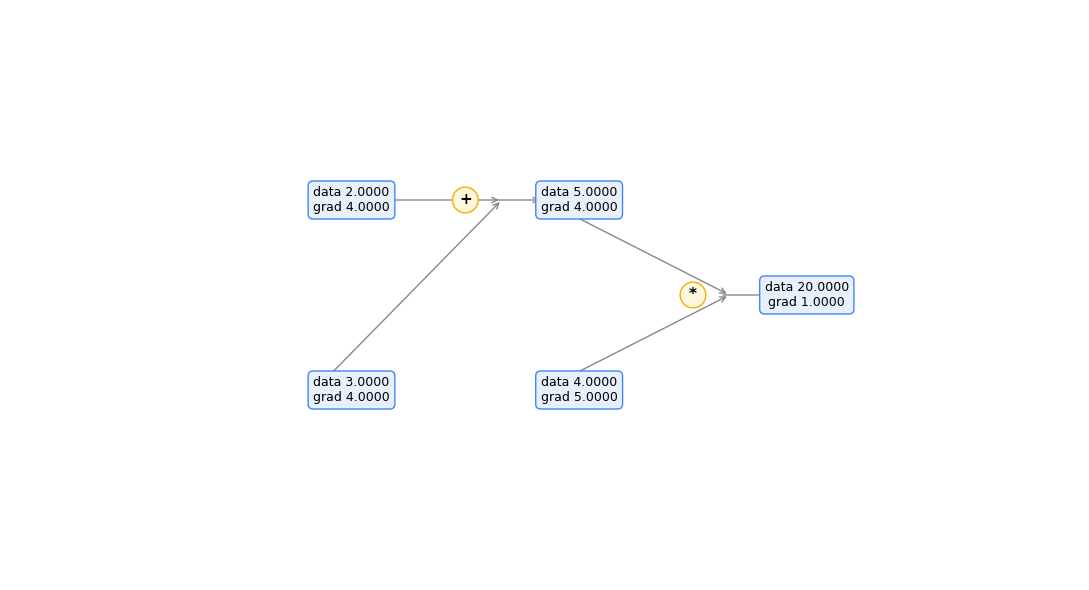

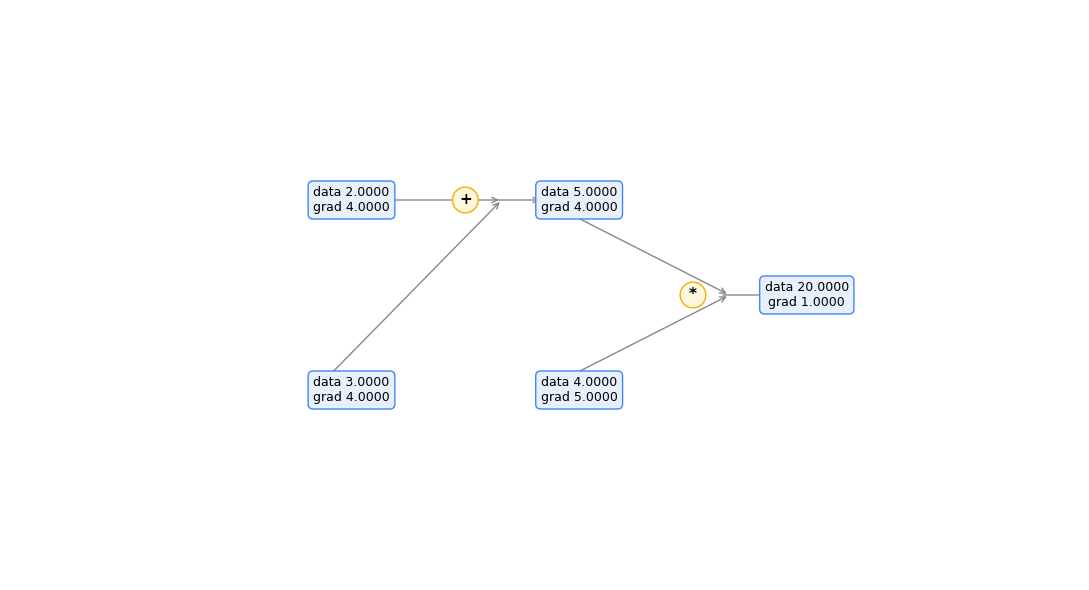

In [14]:
#Adım 1: Çıkış Düğümü (e)


e.grad = 1.0 #Çıktının kendisine göre türevi 1.0'dır

#Adım 2: e'den geriye(c ve d düğümleri)
# e = c x d işlemi bir çarpma işlemidir. Çarpmanın yerel türev kuralı: Gelen gradyanı diğer girdinin değeriyle çarp.
d.grad = e.grad * c.data # d değerini 1 birim artırırsak, nihai sonuç (e) 5 birim artar. Bu nedenle d'nin gradyanı 5'tir.
c.grad = e.grad * d.data # c değerini 1 birim artırırsak, nihai sonuç (e) 4 birim artar. Bu nedenle c'nin gradyanı 4'tür.

#Adım 3: c'den geriye(a ve b düğümleri)
# c = a + b işlemi bir toplama işlemidir. Toplamanın yerel türev kuralı: Gelen gradyanı aynen iletir.
a.grad = c.grad * 1.0 # a değerini 1 birim artırırsak, nihai sonuç (e) 4 birim artar. Bu nedenle a'nın gradyanı 4'tür.
b.grad = c.grad * 1.0 # b değerini 1 birim artırırsak, nihai sonuç (e) 4 birim artar. Bu nedenle b'nin gradyanı 4'tür.

draw_dot(e)



In [15]:
x1 = Value(2.0)
x2 = Value(0.0)

w1 = Value(-3.0)
w2 = Value(1.0)

b = Value(6.8813735870195432) 

x1w1 = x1 * w1
x2w2 = x2 * w2

x1w1x2w2 = x1w1 + x2w2

n = x1w1x2w2 + b



#İLERİ YAYILIM


In [16]:
#GERİ YAYILIM
'''
o.grad = 1.0

n.grad = o.grad * (1 - o.data ** 2) #tanh'in türevi 1 - tanh^2(x) olduğundan, n'in gradyanı 0.07065082485316443'tür.

# n = x1w1x2w2 + b işlemi toplama işlemidir. Toplamanın yerel türev kuralı: Gelen gradyanı aynen iletir.
b.grad = n.grad
x1w1x2w2.grad = n.grad

# x1w1x2w2 = x1w1 + x2w2 işlemi toplama işlemidir. Toplamanın yerel türev kuralı: Gelen gradyanı aynen iletir.
x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

# x1w1 = x1 * w1 işlemi ve x2w2 = x2 * w2 işlemi çarpma işlemidir. Çarpmanın yerel türev kuralı: Gelen gradyanı diğer girdinin değeriyle çarp.
x1.grad = x1w1.grad * w1.data
w1.grad = x1w1.grad * x1.data

x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data

print("w1:", w1.data, "w1.grad:", f"{w1.grad:.4f}")
print("w2:", w2.data, "w2.grad:", f"{w2.grad:.4f}")
print("b:", b.data, "b.grad:", f"{b.grad:.4f}")
'''

'\no.grad = 1.0\n\nn.grad = o.grad * (1 - o.data ** 2) #tanh\'in türevi 1 - tanh^2(x) olduğundan, n\'in gradyanı 0.07065082485316443\'tür.\n\n# n = x1w1x2w2 + b işlemi toplama işlemidir. Toplamanın yerel türev kuralı: Gelen gradyanı aynen iletir.\nb.grad = n.grad\nx1w1x2w2.grad = n.grad\n\n# x1w1x2w2 = x1w1 + x2w2 işlemi toplama işlemidir. Toplamanın yerel türev kuralı: Gelen gradyanı aynen iletir.\nx1w1.grad = x1w1x2w2.grad\nx2w2.grad = x1w1x2w2.grad\n\n# x1w1 = x1 * w1 işlemi ve x2w2 = x2 * w2 işlemi çarpma işlemidir. Çarpmanın yerel türev kuralı: Gelen gradyanı diğer girdinin değeriyle çarp.\nx1.grad = x1w1.grad * w1.data\nw1.grad = x1w1.grad * x1.data\n\nx2.grad = x2w2.grad * w2.data\nw2.grad = x2w2.grad * x2.data\n\nprint("w1:", w1.data, "w1.grad:", f"{w1.grad:.4f}")\nprint("w2:", w2.data, "w2.grad:", f"{w2.grad:.4f}")\nprint("b:", b.data, "b.grad:", f"{b.grad:.4f}")\n'

Görev 3: backward() metodunu yaz: çıktının gradient'ini 1 yap, node'ları ters topological sırayla gez, her node'da chain rule uygula. Bir değişken birden fazla yerde kullanılıyorsa gradient'leri topla, üzerine yazma. (1:09:02 - 1:27:05)

In [17]:

""" o = n.tanh()

o.data

o.backward()

print("w1.grad:", w1.grad)

print("w2.grad:", w2.grad)
print("b.grad:", b.grad) """

# w1.grad: 0.9999999999999998
# w2.grad: 0.0
# b.grad: 0.4999999999999999


' o = n.tanh()\n\no.data\n\no.backward()\n\nprint("w1.grad:", w1.grad)\n\nprint("w2.grad:", w2.grad)\nprint("b.grad:", b.grad) '

In [ ]:
#4. görev tanhı parçala
e = (2*n).exp()
o = (e - 1) / (e+1)

o.backward()


print("o.data: ", o.data)
print("w1.grad:", w1.grad)
print("w2.grad:", w2.grad)
print("b.grad: ", b.grad)




# w1.grad: 1.0
# w2.grad: 0.0
# b.grad:  0.5


o.data:  0.7071067811865477
w1.grad: 1.0
w2.grad: 0.0
b.grad:  0.5


In [19]:
import torch

# PyTorch tensörleri (türev takibi için requires_grad=True)
x1 = torch.Tensor([2.0]).double()
x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()
w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()
w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()
b.requires_grad = True

# İleri yayılım
n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

# Geri yayılım
o.backward()

print("--- PyTorch Sonuçları ---")
print("o.data: ", o.data.item())
print("w1.grad:", w1.grad.item())
print("w2.grad:", w2.grad.item())
print("b.grad: ", b.grad.item())

--- PyTorch Sonuçları ---
o.data:  0.7071066904050358
w1.grad: 1.0000002567688737
w2.grad: 0.0
b.grad:  0.5000001283844369


5. Görev tamamlanamadı anlamam gereken yerler 3. haftada anlanamazsa veya değinilmezse geri dönülüp bakılacak.